## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Load Data

In [2]:
data_type = 'mean_anom_summer'
defol_2019 = pd.read_csv(f'../data/results_MtPleasant/{data_type}_2019.csv')
defol_2020 = pd.read_csv(f'../data/results_MtPleasant/{data_type}_2020.csv')
defol_2021 = pd.read_csv(f'../data/results_MtPleasant/{data_type}_2021.csv')
defol_2022 = pd.read_csv(f'../data/results_MtPleasant/{data_type}_2022.csv')

## Analysis

In [3]:
def percent_defol(df, upper_cutoff, lower_cutoff):
    mask = (df['stat'] <= lower_cutoff) & (df['stat'] > upper_cutoff)
    return df.loc[mask, 'stat'].count() / df['stat'].count()

print(f'% defoliated in 2019: {percent_defol(defol_2019, -1.0, -0.28)}')
print(f'% defoliated in 2020: {percent_defol(defol_2020, -1.0, -0.28)}')
print(f'% defoliated in 2021: {percent_defol(defol_2021, -1.0, -0.28)}')
print(f'% defoliated in 2022: {percent_defol(defol_2022, -1.0, -0.28)}')

% defoliated in 2019: 0.0
% defoliated in 2020: 0.0
% defoliated in 2021: 0.01134885920321551
% defoliated in 2022: 0.0


In [37]:
dfs = [defol_2019, defol_2020, defol_2021, defol_2022]
severe = [percent_defol(df, -1.0, -0.18)*100 for df in dfs]
slight = [percent_defol(df, -0.18, -0.08)*100 for df in dfs]
none = [percent_defol(df, -0.08, 1)*100 for df in dfs]

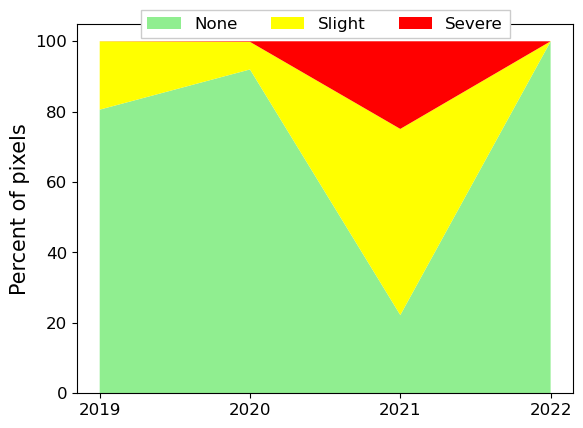

In [47]:
years = [2019, 2020, 2021, 2022]
plt.stackplot(years, none, slight, severe, labels = [r'None', 'Slight', r'Severe'], colors = ['lightgreen', 'yellow', 'red'])
plt.ylabel('Percent of pixels', fontsize=15)
plt.xticks([2019, 2020, 2021, 2022], fontsize=12)
plt.yticks(fontsize=12)
plt.legend(loc='upper center', bbox_to_anchor= (0.5, 1.06),#(1.55, 0.5),
          ncol=3, fancybox=False, shadow=False, framealpha = 1.0, fontsize=12)

plt.savefig('../data/results_MtPleasant/severity_year.svg', bbox_inches ='tight')

In [28]:
def classify(stat):
    if np.isnan(stat):
        return 'nan'
    if (stat > -1.0) and(stat <= -0.18):
        return '2'#'Moderate'
    elif (stat <= -0.08):
        return '1'#'Slight'
    else:
        return '0'#'None'

defol_2019['class'] = defol_2019['stat'].map(classify)
defol_2020['class'] = defol_2020['stat'].map(classify)
defol_2021['class'] = defol_2021['stat'].map(classify)
defol_2022['class'] = defol_2022['stat'].map(classify)

TypeError: Image data of dtype object cannot be converted to float

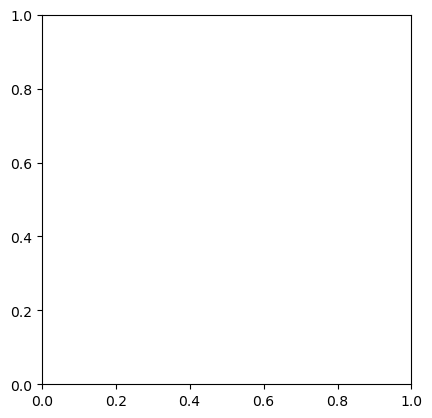

In [29]:
defol_pivot = (defol_2022[['class', 'lat', 'lon']]).pivot(index = 'lat', columns = 'lon')
plt.imshow(defol_pivot, vmin=0, vmax=3)
plt.xticks([])
plt.yticks([])

In [30]:
classes = pd.DataFrame()

classes['2019'] = defol_2019['class']
classes['2020'] = defol_2020['class']
classes['2021'] = defol_2021['class']
classes['2022'] = defol_2022['class']


classes

## Create state transition matrix

### 2019 $\rightarrow$ 2020

In [31]:
classes_2019_2020 = classes[['2019', '2020']].dropna()


index = ['0', '1', '2', '3', 'nan']

transition = pd.DataFrame(0,index=index, columns=index)

for i in range(len(classes)):
    transition.loc[classes_2019_2020.at[i, '2019'], classes_2019_2020.at[i, '2020']] += 1

transition.div(transition.sum(axis=1), axis=0)

,0,1,2,3,nan
0,0.916813,0.081133,0.002054,0.0,0.0
1,0.932968,0.067032,0.000000,0.0,0.0
2,1.000000,0.000000,0.000000,0.0,0.0
3,NaN,NaN,NaN,NaN,NaN
nan,0.000000,0.000000,0.000000,0.0,1.0


### 2020 $\rightarrow$ 2021

In [32]:
classes_2020_2021 = classes[['2020', '2021']].dropna()


index = ['0', '1', '2', '3', 'nan']

transition = pd.DataFrame(0,index=index, columns=index)

for i in range(len(classes)):
    transition.loc[classes_2020_2021.at[i, '2020'], classes_2020_2021.at[i, '2021']] += 1

transition.div(transition.sum(axis=1), axis=0)

,0,1,2,3,nan
0,0.220380,0.522873,0.256746,0.0,0.0
1,0.245852,0.597285,0.156863,0.0,0.0
2,0.142857,0.571429,0.285714,0.0,0.0
3,NaN,NaN,NaN,NaN,NaN
nan,0.000000,0.000000,0.000000,0.0,1.0


### 2021 $\rightarrow$ 2022

In [34]:
classes_2021_2022 = classes[['2021', '2022']].dropna()


index = ['0', '1', '2', '3', 'nan']

transition = pd.DataFrame(0,index=index, columns=index)

for i in range(len(classes)):
    transition.loc[classes_2021_2022.at[i, '2021'], classes_2021_2022.at[i, '2022']] += 1

transition.div(transition.sum(axis=1), axis=0)

,0,1,2,3,nan
0,1.000000,0.000000,0.0,0.0,0.0
1,1.000000,0.000000,0.0,0.0,0.0
2,0.998101,0.001899,0.0,0.0,0.0
3,NaN,NaN,NaN,NaN,NaN
nan,0.000000,0.000000,0.0,0.0,1.0


## Create change transition matrix

In [ ]:
# Create inter-year change states
def create_state(x,y):
    return f'{x}->{y}'

for i in range(len(classes)):
    classes.at[i, '2019->2020'] = create_state(classes['2019'].iloc[i],classes['2020'].iloc[i])
    classes.at[i, '2020->2021'] = create_state(classes['2020'].iloc[i],classes['2021'].iloc[i])
    classes.at[i, '2021->2022'] = create_state(classes['2021'].iloc[i],classes['2022'].iloc[i])

In [ ]:
classes

In [ ]:
index = ['0.0->0.0',
         '0.0->1.0',
         '0.0->2.0',
         '0.0->3.0',
         '1.0->0.0',
         '1.0->1.0',
         '1.0->2.0',
         '1.0->3.0',
         '2.0->0.0',
         '2.0->1.0',
         '2.0->2.0',
         '2.0->3.0',
         '3.0->0.0',
         '3.0->1.0',
         '3.0->2.0',
         '3.0->3.0',
         'nan->nan']

transition = pd.DataFrame(0,index=index, columns=index)

for i in range(len(classes)):
    transition.loc[classes.at[i, '2020->2021'], classes.at[i, '2019->2020']] += 1
    transition.loc[classes.at[i, '2021->2022'], classes.at[i, '2020->2021']] += 1
transition

In [ ]:
plt.imshow(transition)